## Choosing the PDF

- Sampling a Semicircle has to be done via rejection sampling. 
- We already know how to sample an exponential: $\pi(x) = \lambda e^{-\lambda x}\implies X= -\frac{1}{\lambda}\ln(U)$
- We have $\pi(l)= \frac{1}{2a}e^{-\frac{|l|}{a}}$
This is just two exponentials. The 1/2 factor comes because of normalisation but we can get the factor of half by choosing the sign of exponential by probability 1/2

So the sample is 

$X = -a\ln(U)$ with probability $1/2$ and $X = a\ln(U)$ with probability $1/2$

To sample sign with probability $1/2$ I can do sign(U(0,1)-0.5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

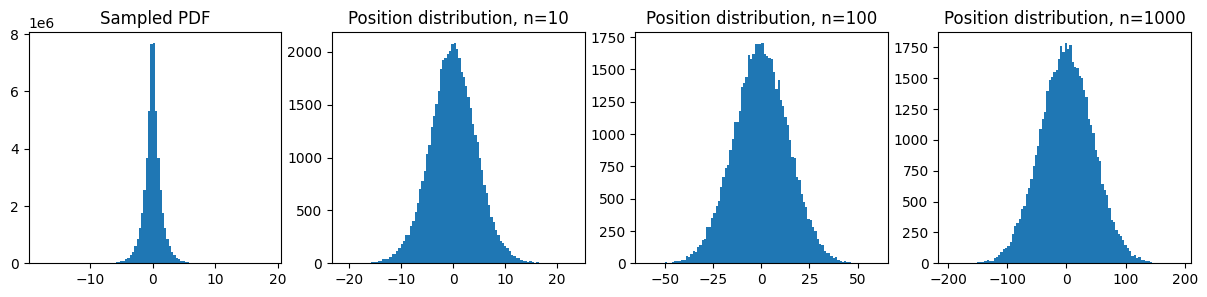

In [24]:
a = 1
rng = np.random.default_rng()

# n is the number of steps each random walker takes and N is the number of random walkers 
# Regardless of how each walker samples its stepsize taken, the distributon of walkers follow a normal distribution

def pos_distrib(a, n, N):

    # each row is a walker and the columns are the steps taken
    U1 = np.sign(rng.uniform(low=0, high=1, size=(N, n))-0.5)
    U2 = rng.uniform(low=0, high=1, size=(N,n))

    two_exp = a*U1*np.log(U2) 

    Xn = np.sum(two_exp, axis=1)

    return two_exp, Xn


two_exp, Xn1 = pos_distrib(a, 10, 50000)
two_exp, Xn2 = pos_distrib(a, 100, 50000)
two_exp, Xn3 = pos_distrib(a, 1000, 50000)

fig, axs = plt.subplots(1,4,figsize=(15,3))
axs[0].hist(two_exp.ravel(), bins=100);
axs[1].hist(Xn1, bins=100)
axs[2].hist(Xn2, bins=100)
axs[3].hist(Xn3, bins=100)

axs[0].set_title('Sampled PDF');
axs[1].set_title('Position distribution, n=10');
axs[2].set_title('Position distribution, n=100');
axs[3].set_title('Position distribution, n=1000');

In [25]:
n_vals = np.linspace(10,1000,50)
sigsn = np.zeros(len(n_vals))

for i in range(len(n_vals)):
    te, xn = pos_distrib(a, int(n_vals[i]), 10000)
    sigsn[i] = np.sqrt(np.mean(xn**2)-np.mean(xn)**2)

Let's derive the error analytically 

- $<L> = \int_{-\infty}^{\infty} l \pi(l) dl = 0$ as $\pi(l)$ is symmetric about 0
- All $l_i=L$ are independent. So $<X_N^2> = \sum_i^n<l_i^2>+\sum_{i\neq j}<l_i l_j> = n<l^2>+\sum_{i\neq j}<l_i><l_j> = n<l^2>$
- Thus $\sigma_X^2= <X^2>-<X>^2 = n<L^2>$

So we need to calculate $<L^2> = \int l^2 \pi(l) dl$ for our given distribution. 

$<L^2> = \int_{-\infty}^0 \frac{l^2}{2a}e^{l/a} dl + \int^{\infty}_0 \frac{l^2}{2a}e^{-l/a} dl = 2a^2$

So $\sigma = \sqrt{n<L^2>} = \sqrt{n\cdot 2a^2} = a\sqrt{2n}$

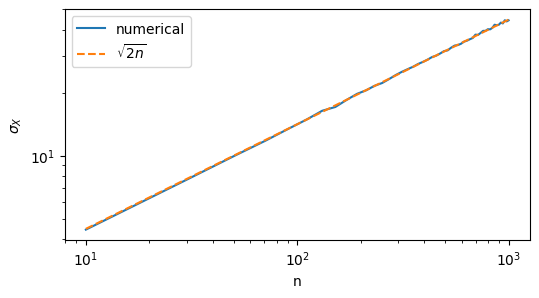

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(n_vals, sigs, label='numerical')
ax.plot(n_vals, np.sqrt(2*n_vals), '--', label=r'$\sqrt{2n}$')
ax.set_xlabel('n');
ax.set_ylabel(r'$\sigma_X$');
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend();

In [27]:
a_vals = np.linspace(1, 50, 50)
sigsa = np.zeros(len(a_vals))

for i in range(len(a_vals)):
    te, xn = pos_distrib(a_vals[i], int(100), 10000)
    sigsa[i] = np.sqrt(np.mean(xn**2)-np.mean(xn)**2)

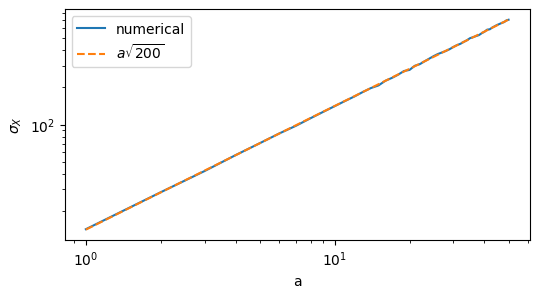

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(a_vals, sigsa, label='numerical')
ax.plot(a_vals, a_vals*np.sqrt(2*100), '--', label=r'$a\sqrt{200}$')
ax.set_xlabel('a')
ax.set_ylabel(r'$\sigma_X$')
ax.set_xscale('log');
ax.set_yscale('log');
ax.legend();